# __KNN Project(Global Agricultural Emissions Analysis)__

## __Problem Statement:__
- Agriculture is a significant source of global greenhouse gas (GHG) emissions, including methane, nitrous oxide, and carbon dioxide. These emissions vary across countries, years, and agricultural activities. Due to the large volume of emission data, it is difficult to manually analyze patterns and relationships between factors such as area, year, item type, and emission values. Therefore, a data-driven approach is required to analyze agricultural emission patterns and develop predictive models for classifying emission categories.

### Objective:
- To perform data preprocessing, exploratory data analysis, and apply machine learning algorithms to identify patterns and predict emission categories from agricultural emission datasets.

### Steps to be followed:
1. Import the required library
2. Load the data
3. Check for null values
4. Analyze the data column distribution
5. Balance the data
6. Encode of the full dataset
7. Split and train the dataset
8. Perform feature scaling on the dataset
9. Compile the model
10. Fit the model
11. Print the model
12. Evaluate the metrics


## Step 1: Import the Required Library
- Import the essential libraries for data manipulation and analysis, such as NumPy and Pandas, and use PyMySQL for database connectivity, LabelEncoder for data preprocessing, and Matplotlib for visualization

In [12]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score,classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder,LabelEncoder, StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Data
- Load a CSV file named **loan_data.csv** into a Pandas DataFrame named **df**
- Display the initial few rows of the **df** DataFrame

In [13]:
df=pd.read_csv(r"C:\Users\kpasw\OneDrive\Desktop\Datasets\Data sets\global greenhouse gas emissions from agriculture.csv")
df

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Source Code,Source,Unit,Value,Flag,Flag Description,Note
0,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1990,1990,3050,FAO TIER 1,kt,214.4467,E,Estimated value,NaN
1,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1991,1991,3050,FAO TIER 1,kt,224.1393,E,Estimated value,NaN
2,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1992,1992,3050,FAO TIER 1,kt,226.7224,E,Estimated value,NaN
3,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1993,1993,3050,FAO TIER 1,kt,228.5003,E,Estimated value,NaN
4,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1994,1994,3050,FAO TIER 1,kt,236.9822,E,Estimated value,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22211,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2017,2017,3050,FAO TIER 1,kt,15.4064,E,Estimated value,NaN
22212,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2018,2018,3050,FAO TIER 1,kt,15.4385,E,Estimated value,NaN
22213,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2019,2019,3050,FAO TIER 1,kt,15.0984,E,Estimated value,NaN
22214,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2020,2020,3050,FAO TIER 1,kt,13.4151,E,Estimated value,NaN


## Step 3:Data Cleaning and Preprocessing

In [14]:
df.describe()

,Area Code (M49),Element Code,Item Code,Year Code,Year,Source Code,Value,Note
count,22216.000000,22216.000000,22216.0,22216.000000,22216.000000,22216.0,2.221600e+04,0.0
mean,436.902008,7242.692114,6995.0,2005.622344,2005.622344,3050.0,8.487653e+03,NaN
std,253.450163,21.551371,0.0,9.183770,9.183770,0.0,6.420424e+04,NaN
min,4.000000,7225.000000,6995.0,1990.000000,1990.000000,3050.0,0.000000e+00,NaN
25%,218.000000,7225.000000,6995.0,1998.000000,1998.000000,3050.0,1.946475e+00,NaN
50%,434.000000,7230.000000,6995.0,2006.000000,2006.000000,3050.0,3.849290e+01,NaN
75%,659.000000,7273.000000,6995.0,2014.000000,2014.000000,3050.0,7.815779e+02,NaN
max,894.000000,7273.000000,6995.0,2021.000000,2021.000000,3050.0,1.660373e+06,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22216 entries, 0 to 22215
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       22216 non-null  object 
 1   Domain            22216 non-null  object 
 2   Area Code (M49)   22216 non-null  int64  
 3   Area              22216 non-null  object 
 4   Element Code      22216 non-null  int64  
 5   Element           22216 non-null  object 
 6   Item Code         22216 non-null  int64  
 7   Item              22216 non-null  object 
 8   Year Code         22216 non-null  int64  
 9   Year              22216 non-null  int64  
 10  Source Code       22216 non-null  int64  
 11  Source            22216 non-null  object 
 12  Unit              22216 non-null  object 
 13  Value             22216 non-null  float64
 14  Flag              22216 non-null  object 
 15  Flag Description  22216 non-null  object 
 16  Note              0 non-null      float6

In [16]:
df.isna().mean()*100

Domain Code           0.0
Domain                0.0
Area Code (M49)       0.0
Area                  0.0
Element Code          0.0
Element               0.0
Item Code             0.0
Item                  0.0
Year Code             0.0
Year                  0.0
Source Code           0.0
Source                0.0
Unit                  0.0
Value                 0.0
Flag                  0.0
Flag Description      0.0
Note                100.0
dtype: float64

In [17]:
df.drop(["Note"],axis=1,inplace=True)

In [18]:
df.isna().sum()

Domain Code         0
Domain              0
Area Code (M49)     0
Area                0
Element Code        0
Element             0
Item Code           0
Item                0
Year Code           0
Year                0
Source Code         0
Source              0
Unit                0
Value               0
Flag                0
Flag Description    0
dtype: int64

<Axes: >

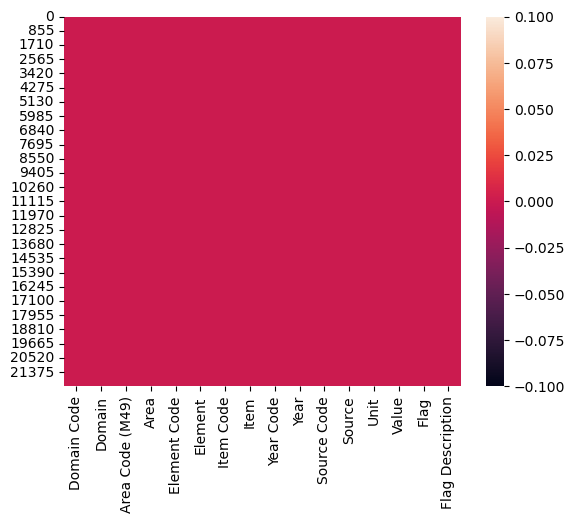

In [19]:
sns.heatmap(df.isna())

## Step 4: Exploratory Data Analysis (EDA)
- Visualizations are used to understand relationships between variables and battery health.

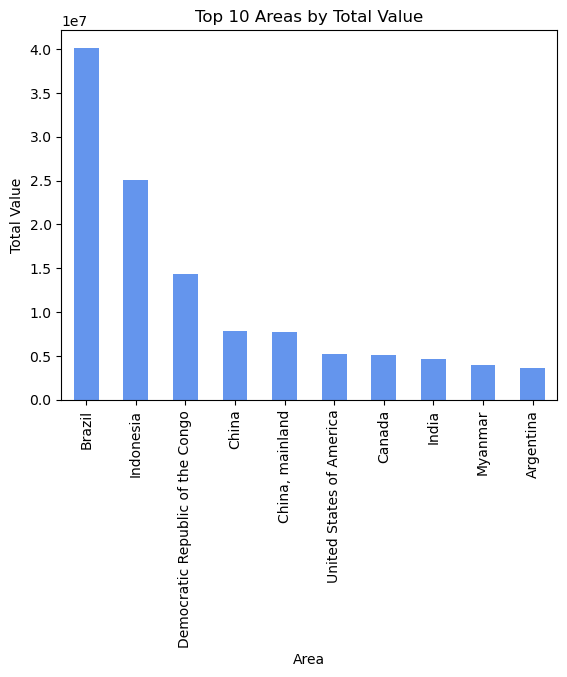

In [20]:
plt.figure()
df.groupby('Area')['Value'].sum().sort_values(ascending=False).head(10)\
  .plot.bar(color='cornflowerblue')
plt.title('Top 10 Areas by Total Value')
plt.ylabel('Total Value')
plt.xlabel('Area')
plt.show()


### Observation:
- Brazil has the highest total emission value in agricultural activities.
- Indonesia and the Republic of the Congo also show high emission values.
- Other countries like China, the United States, and India contribute moderately to total emissions.

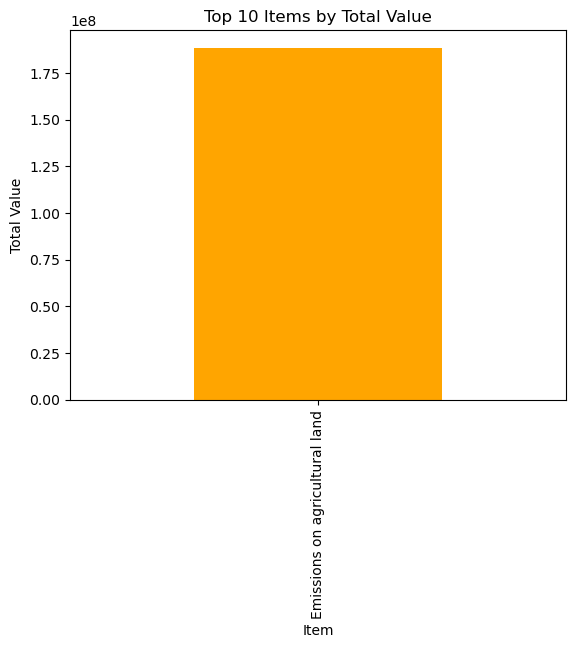

In [21]:
plt.figure()
df.groupby('Item')['Value'].sum().sort_values(ascending=False).head(10)\
  .plot.bar(color='orange')
plt.title('Top 10 Items by Total Value')
plt.ylabel('Total Value')
plt.xlabel('Item')
plt.show()


### Observation:
- Emissions on agricultural land has the highest total emission value among all items.
- It contributes significantly more than other agricultural emission categories in the dataset.

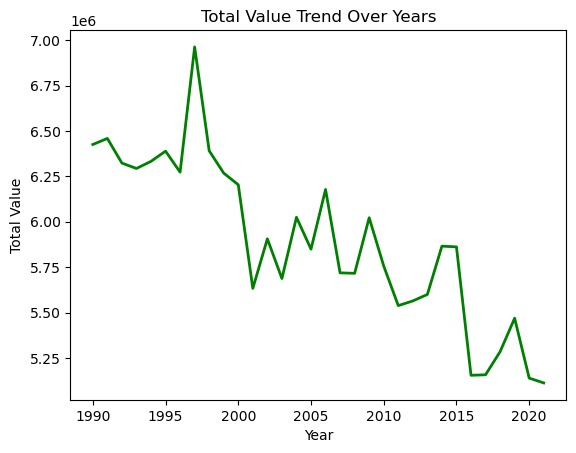

In [22]:
plt.figure()
df.groupby('Year')['Value'].sum().plot(
    color='green', linewidth=2
)
plt.title('Total Value Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total Value')
plt.show()


### Observation:
- The line chart shows fluctuations in total emission values over the years. Emissions reach a peak around the late 1990s and then gradually decline in the following years, indicating a slight downward trend over time.

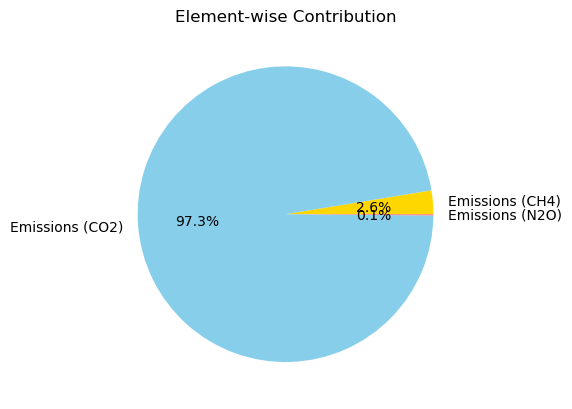

In [23]:
plt.figure()
df.groupby('Element')['Value'].sum().plot.pie(
    autopct='%1.1f%%',
    colors=['gold','skyblue','lightcoral','lightgreen']
)
plt.title('Element-wise Contribution')
plt.ylabel('')
plt.show()


### Observation:
- The pie chart shows that CO₂ emissions contribute the largest share (about 97%) of the total emissions. In comparison, CH₄ (methane) and N₂O (nitrous oxide) contribute only a very small percentage to the overall emissions.

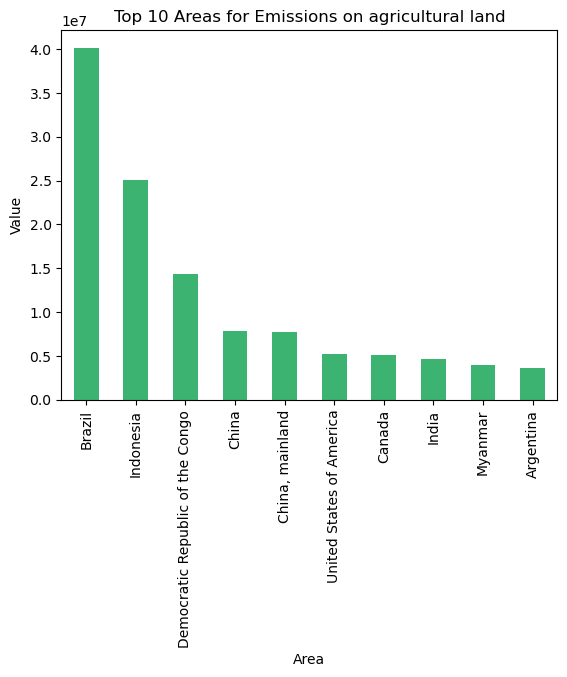

In [24]:
top_item = df['Item'].value_counts().idxmax()

plt.figure()
df[df['Item'] == top_item].groupby('Area')['Value'].sum()\
  .sort_values(ascending=False).head(10)\
  .plot.bar(color='mediumseagreen')

plt.title(f'Top 10 Areas for {top_item}')
plt.ylabel('Value')
plt.xlabel('Area')
plt.show()


### Observation:
- Brazil has the highest emissions on agricultural land, followed by Indonesia and the Republic of the Congo. Other countries such as China, the United States, and India also contribute notable emission values.

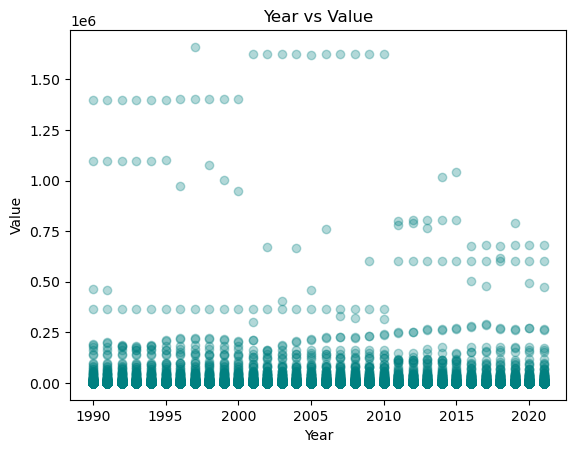

In [25]:
plt.figure()
plt.scatter(df['Year'], df['Value'], alpha=0.3, color='teal')
plt.title('Year vs Value')
plt.xlabel('Year')
plt.ylabel('Value')
plt.show()


### Observation:
- The scatter plot shows that emission values vary widely across different years. Most values remain relatively low, while a few data points show significantly higher emission values. This indicates variability in agricultural emissions over time.

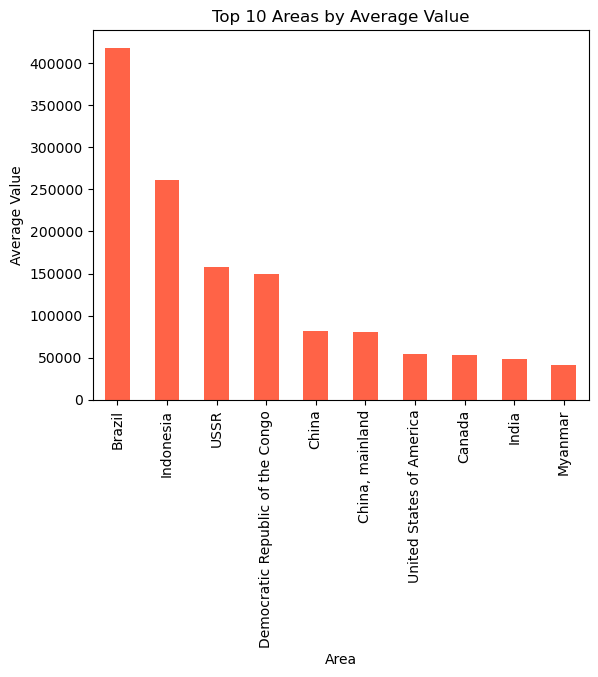

In [26]:
plt.figure()
df.groupby('Area')['Value'].mean().sort_values(ascending=False).head(10)\
  .plot.bar(color='tomato')
plt.title('Top 10 Areas by Average Value')
plt.ylabel('Average Value')
plt.xlabel('Area')
plt.show()


### Observation:

- Brazil has the highest average emission value among all areas. Indonesia and the USSR also show relatively high average emissions, while countries like India, Canada, and Myanmar have lower average values in comparison.

### Encoding Categorical Data
-This step prepares the categorical feature for model training.

In [27]:
label=LabelEncoder()
cat_cols=['Domain Code','Domain','Area','Flag Description','Item','Source','Unit','Flag']
for col in cat_cols:
    df[col]=df[col].astype(str)
    df[col]=label.fit_transform(df[col])

## Step 5: Feature–Target Separation

In [28]:
x= df.drop(columns=['Element'])
y=df['Element']

### Feature Scaling (Standardization).

In [29]:
scaler=StandardScaler()
x_scaled= scaler.fit_transform(x)

### Traing and Testing the Features (Train-Test Splitting)
- Prevents overfitting
- Allows evaluation on unseen data

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

## Step 6: Model Initialization & Model Training

In [31]:
knn= KNeighborsClassifier()
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Making Predictions
- model is going to predict the target values for the test dataset.
- These predictions will be used to evaluate the model’s performance.

In [32]:
y_pred=knn.predict(x_test)

## Step 7: Model Evaluation
#### Model performance is evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report

In [33]:
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

Emissions (CH4)       0.96      0.96      0.96      1489
Emissions (CO2)       1.00      1.00      1.00      1504
Emissions (N2O)       0.96      0.95      0.95      1451

       accuracy                           0.97      4444
      macro avg       0.97      0.97      0.97      4444
   weighted avg       0.97      0.97      0.97      4444



# Conclusion
- Agricultural emissions vary across different countries and years.
- Brazil and Indonesia are the highest contributors to emissions.
- CO₂ is the dominant emission type compared to CH₄ and N₂O.
- Emission values fluctuate over time with a slight decreasing trend.

# Model with Grid SearchCV

In [34]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

In [35]:
x = x.select_dtypes(include='number')


In [36]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',KNeighborsClassifier())
])


In [37]:

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}



In [38]:
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,             
    scoring='accuracy',
    n_jobs=-1         
)

grid.fit(x_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [39]:
print(grid.best_params_)


{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [40]:
print(grid.best_score_)


0.9959487339001953


In [41]:
best_knn = grid.best_estimator_


In [42]:
test_accuracy = best_knn.score(x_test, y_test)
print("Test accuracy:", test_accuracy)


Test accuracy: 0.9979747974797479


In [43]:
print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

Emissions (CH4)       0.96      0.96      0.96      1489
Emissions (CO2)       1.00      1.00      1.00      1504
Emissions (N2O)       0.96      0.95      0.95      1451

       accuracy                           0.97      4444
      macro avg       0.97      0.97      0.97      4444
   weighted avg       0.97      0.97      0.97      4444

